In [4]:
# Numerical libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train test split
from sklearn.model_selection import train_test_split

# SVM model
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [6]:
from google.colab import files
df = files.upload()

#Read exel file
df = pd.read_excel('logistic_regression_CaseStudy.xlsx')
# Display first  rows
df.head()


Saving logistic_regression_CaseStudy.xlsx to logistic_regression_CaseStudy (1).xlsx


,Employee_ID,Age,Gender,Department,Education_Level,Years_of_Experience,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Job_Satisfaction_Score,Promotion_Last_2_Years,Remote_Work,Training_Hours,Attrition_Flag
0,1,59,Female,Marketing,Diploma,34,53281,33,13,10,0,1,17,0
1,2,49,Female,IT,Master,27,92275,57,1,10,1,0,75,0
2,3,35,Male,Operations,PhD,15,26525,45,12,3,0,0,83,0
3,4,28,Female,Sales,Bachelor,7,41453,68,2,4,0,1,48,1
4,5,41,Male,IT,Diploma,17,31251,54,10,3,0,1,47,0


In [7]:
# Shape of dataset
print(df.shape)

# Column names
print(df.columns)

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

(10000, 14)
Index(['Employee_ID', 'Age', 'Gender', 'Department', 'Education_Level',
       'Years_of_Experience', 'Monthly_Salary', 'Work_Hours_Per_Week',
       'Projects_Handled', 'Job_Satisfaction_Score', 'Promotion_Last_2_Years',
       'Remote_Work', 'Training_Hours', 'Attrition_Flag'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Employee_ID             10000 non-null  int64 
 1   Age                     10000 non-null  int64 
 2   Gender                  10000 non-null  object
 3   Department              10000 non-null  object
 4   Education_Level         10000 non-null  object
 5   Years_of_Experience     10000 non-null  int64 
 6   Monthly_Salary          10000 non-null  int64 
 7   Work_Hours_Per_Week     10000 non-null  int64 
 8   Projects_Handled        10000 non-null  int64 
 9   

In [8]:
# Check null values
print(df.isnull().sum())

Employee_ID               0
Age                       0
Gender                    0
Department                0
Education_Level           0
Years_of_Experience       0
Monthly_Salary            0
Work_Hours_Per_Week       0
Projects_Handled          0
Job_Satisfaction_Score    0
Promotion_Last_2_Years    0
Remote_Work               0
Training_Hours            0
Attrition_Flag            0
dtype: int64


In [9]:
df.columns = df.columns.str.strip()

In [10]:
print(df.columns)

Index(['Employee_ID', 'Age', 'Gender', 'Department', 'Education_Level',
       'Years_of_Experience', 'Monthly_Salary', 'Work_Hours_Per_Week',
       'Projects_Handled', 'Job_Satisfaction_Score', 'Promotion_Last_2_Years',
       'Remote_Work', 'Training_Hours', 'Attrition_Flag'],
      dtype='object')


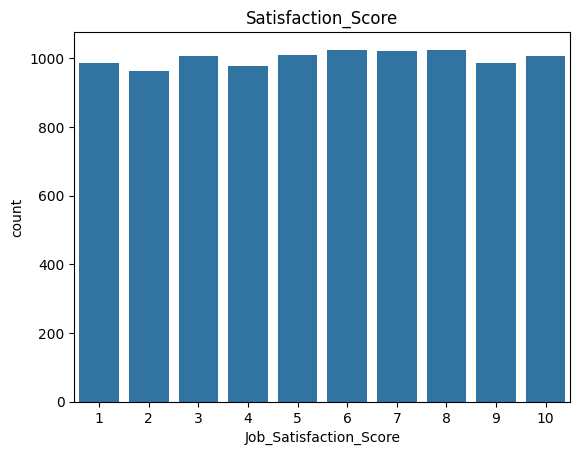

In [12]:
sns.countplot(x='Job_Satisfaction_Score', data=df)

plt.title("Satisfaction_Score")

plt.show()

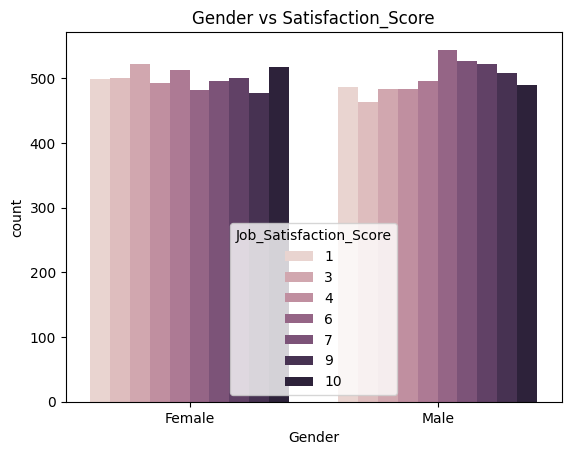

In [14]:
sns.countplot(x='Gender',
              hue='Job_Satisfaction_Score',
              data=df)

plt.title("Gender vs Satisfaction_Score")

plt.show()

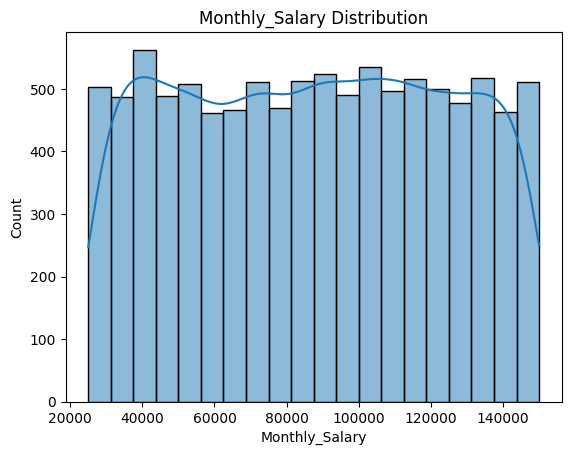

In [15]:
sns.histplot(df['Monthly_Salary'],
             bins=20,
             kde=True)

plt.title("Monthly_Salary Distribution")

plt.show()

In [16]:
Categorical_col = df.select_dtypes(include = 'object').columns
Categorical_col

Index(['Gender', 'Department', 'Education_Level'], dtype='object')

In [18]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df['Department'] = le.fit_transform(df['Department'])

df['Education_Level'] = le.fit_transform(df['Education_Level'])

In [19]:
X = df.drop('Promotion_Last_2_Years', axis=1)
y = df['Promotion_Last_2_Years']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

svm_model = SVC(
    kernel='linear',
    C=1
)

svm_model.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [20]:
y_pred = svm_model.predict(X_test)

print(y_pred)

[0 0 0 ... 0 0 0]


In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7965


[[1593    0]
 [ 407    0]]


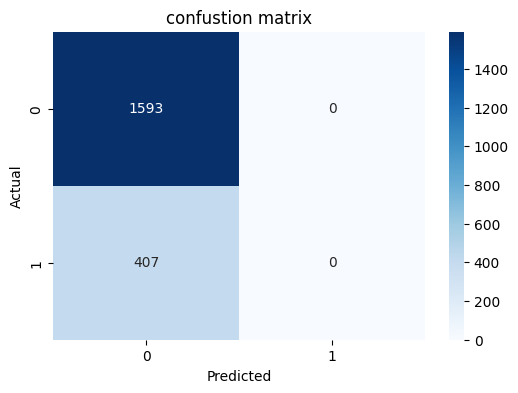

In [22]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("confustion matrix")
plt.show()

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1593
           1       0.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
svm_rbf = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

svm_rbf.fit(X_train, y_train)

rbf_pred = svm_rbf.predict(X_test)

print("RBF Accuracy:",
      accuracy_score(y_test, rbf_pred))

RBF Accuracy: 0.7965


In [25]:
svm_rbf.fit(X_train, y_train)

rbf_pred = svm_rbf.predict(X_test)

print("RBF Accuracy:",
      accuracy_score(y_test, rbf_pred))

svm_poly = SVC(
    kernel='poly',
    degree=3
)

svm_poly.fit(X_train, y_train)

poly_pred = svm_poly.predict(X_test)

print("Polynomial Accuracy:",
      accuracy_score(y_test, poly_pred))

RBF Accuracy: 0.7965
Polynomial Accuracy: 0.7965


In [26]:
from sklearn.model_selection import GridSearchCV

In [27]:

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

In [28]:
grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True,
    verbose=2
)

In [29]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   2.6s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   3.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   3.3s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   2.6s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   2.6s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.7s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.7s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.7s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.7s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.8s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   3.2s
[CV] END .......................C=0.1, gamma=0.1

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.01],
                         'kernel': ['rbf', 'linear']},
             verbose=2)

In [30]:
print(grid.best_params_)

{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}


In [31]:
print(grid.best_estimator_)

SVC(C=0.1, gamma=1)


In [32]:
best_model = grid.best_estimator_

final_prediction = best_model.predict(X_test)

print("Final Accuracy:",
      accuracy_score(y_test, final_prediction))

Final Accuracy: 0.7965
